# Exploratory Data Analysis: Cyber-Economic Intersections (2014-2026)
This section loads the processed data and performs an initial sanity check on the data structures and missing values.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings

# Visual settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_csv('../datasets/processed/processed_cyber_data.csv')

# Tabular Visualization
print("### Dataset Snapshot (First 5 Rows)")
display(df.head())

print("\n### Data Info & Missing Values")
display(df.info())

### Dataset Snapshot (First 5 Rows)


,iso3,year,motive,actor_type,event_type,source,weighted_intensity,offline_conflict_intensity,economy,inflation_cpi,gdp_per_capita,political_stability
0,AFG,2015.0,Data theft,NaN,NaN,EuRepoC,2.0,Unknown,AFG,-0.661709,565.569730,23.510621
1,AFG,2016.0,Undetermined,Nation-State,Exploitive,Maryland,NaN,NaN,AFG,4.383892,522.082216,23.472362
2,AFG,2016.0,Protest,Hacktivist,Disruptive,Maryland,NaN,NaN,AFG,4.383892,522.082216,23.472362
3,AFG,2016.0,Protest,Hacktivist,Disruptive,Maryland,NaN,NaN,AFG,4.383892,522.082216,23.472362
4,AFG,2016.0,Protest,Hacktivist,Disruptive,Maryland,NaN,NaN,AFG,4.383892,522.082216,23.472362



### Data Info & Missing Values
<class 'pandas.DataFrame'>
RangeIndex: 17461 entries, 0 to 17460
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   iso3                        17461 non-null  str    
 1   year                        17461 non-null  float64
 2   motive                      17461 non-null  str    
 3   actor_type                  15906 non-null  str    
 4   event_type                  15906 non-null  str    
 5   source                      17461 non-null  str    
 6   weighted_intensity          1555 non-null   float64
 7   offline_conflict_intensity  1555 non-null   str    
 8   economy                     15827 non-null  str    
 9   inflation_cpi               17163 non-null  float64
 10  gdp_per_capita              17212 non-null  float64
 11  political_stability         17444 non-null  float64
dtypes: float64(5), str(7)
memory usage: 1.6 MB


None

In [31]:
# DATA REPAIR

# Year fix
df['year'] = df['year'].fillna(0).astype(int)

# Extract PRIMARY values safely
df['motive_clean'] = (
    df['motive']
    .fillna('Unknown')
    .astype(str)
    .str.split(';')
    .apply(lambda x: x[0].strip() if len(x) > 0 else 'Unknown')
)

df['actor_clean'] = (
    df['actor_type']
    .fillna('Unknown/Unattributed')
    .astype(str)
    .str.split(';')
    .apply(lambda x: x[0].strip() if len(x) > 0 else 'Unknown/Unattributed')
)

## Statistical Summary
Before visualizing, we look at the distribution of our economic indicators and cyber intensity scores to identify outliers.

In [32]:
# Tabular Visualization: Summary Statistics
print("### Summary Statistics for Numerical Features")
display(df[['weighted_intensity', 'gdp_per_capita', 'inflation_cpi', 'political_stability']].describe())

# Check for remaining nulls in economic data after forward-fill
print("\n### Null Count per Column (Post-Cleaning)")
display(df.isnull().sum().to_frame(name='Missing Values'))

### Summary Statistics for Numerical Features


,weighted_intensity,gdp_per_capita,inflation_cpi,political_stability
count,1555.000000,17212.000000,17163.000000,17444.000000
mean,2.652733,50359.232400,5.333418,66.269638
std,1.482301,27424.219059,13.946788,10.371325
min,0.000000,356.496214,-12.296984,21.188072
25%,1.000000,30799.477594,1.625865,62.595315
50%,3.000000,56572.918900,2.949525,64.269720
75%,4.000000,70205.050916,5.597018,73.207361
max,9.000000,206780.590353,254.948535,93.961320



### Null Count per Column (Post-Cleaning)


,Missing Values
iso3,0
year,0
motive,0
actor_type,1555
event_type,1555
source,0
weighted_intensity,15906
offline_conflict_intensity,15906
economy,1634
inflation_cpi,298


## Cyber Attack Volume Over Time
Compare the raw count of incidents year-over-year.

### Annual Incident Totals


,Incident Count
year,
2014,669
2015,893
2016,1153
2017,863
2018,858
2019,1080
2020,1722
2021,1459
2022,2674


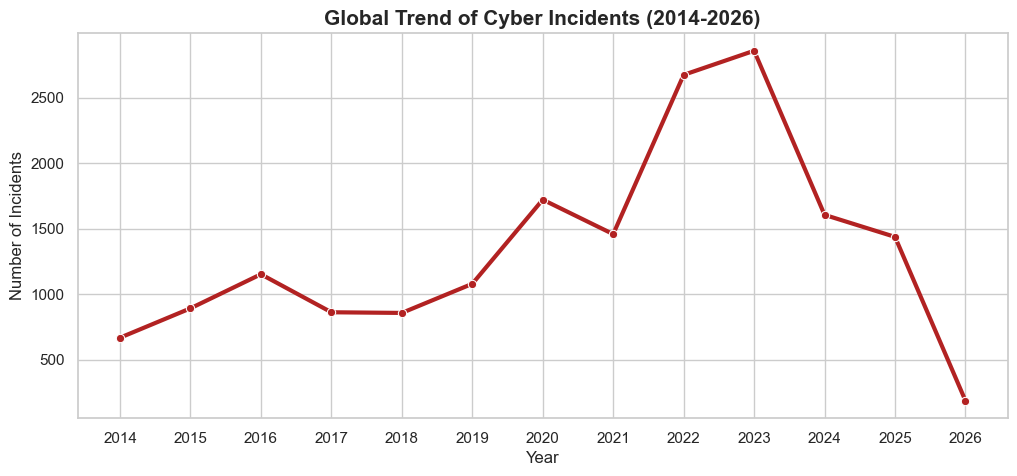

In [33]:
# Tabular Visualization: Annual Counts
yearly_counts = df['year'].value_counts().sort_index().to_frame(name='Incident Count')
print("### Annual Incident Totals")
display(yearly_counts)

# Graphical Visualization
plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly_counts, x=yearly_counts.index, y='Incident Count', marker='o', color='firebrick', linewidth=3)
plt.title('Global Trend of Cyber Incidents (2014-2026)', fontsize=15, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Incidents')
plt.xticks(yearly_counts.index)

plt.savefig('../plots/temporal_trends.png', dpi=300, bbox_inches='tight')
plt.show()

## Attack Motives and Actor Profiles
Analyzing the distribution of qualitative variables from the Maryland and EuRepoC datasets.

### Top 5 Motives and Actor Types


,Count
motive_clean,
Financial,9257
Undetermined,3341
Protest,1871
Political-Espionage,810
Disruption,602


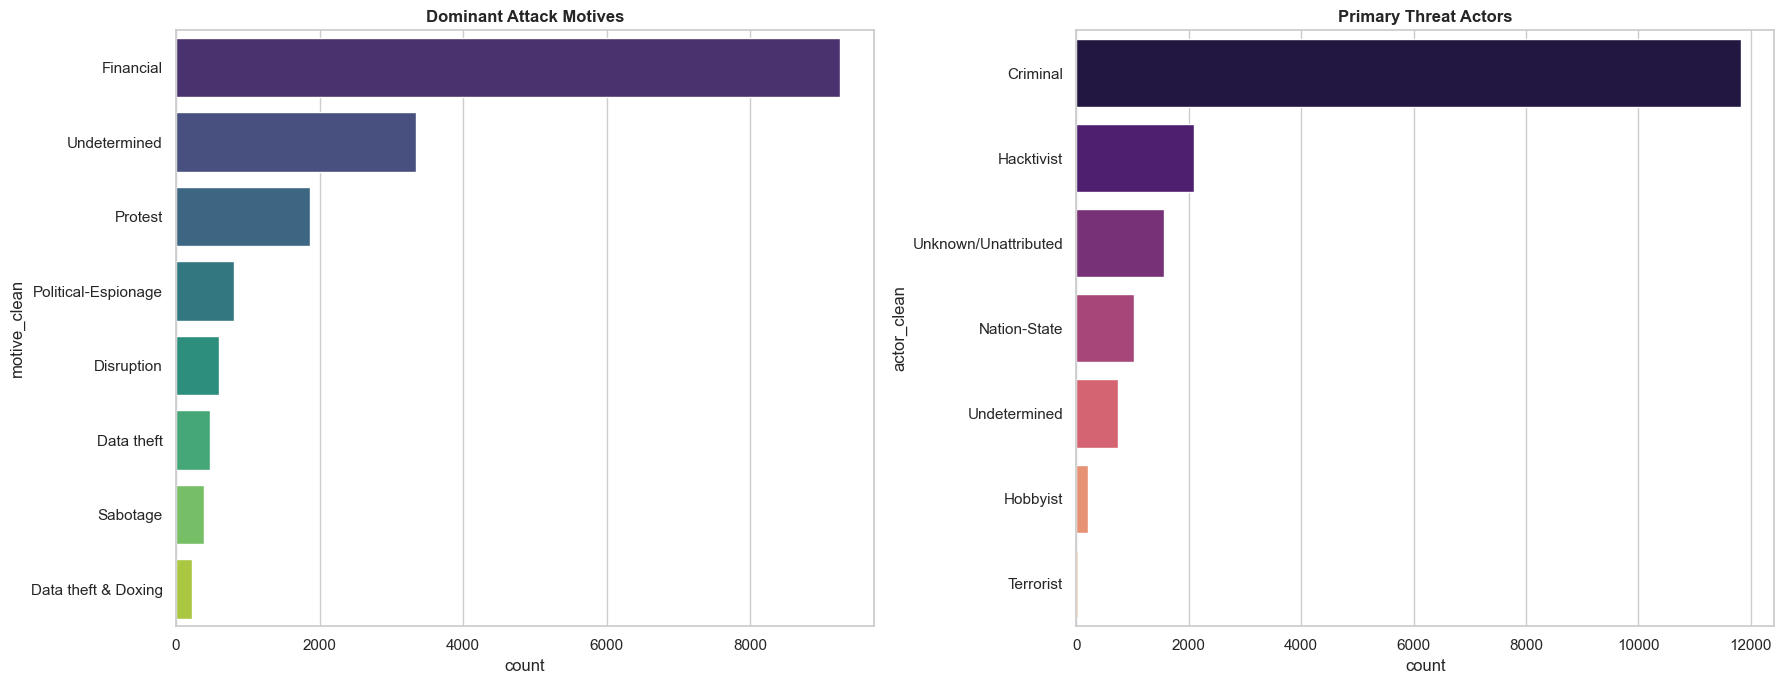

In [34]:
# Tabular Visualization:
print("### Top 5 Motives and Actor Types")
display(df['motive_clean'].value_counts().head(5).to_frame(name='Count'))

# Graphical Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.countplot(data=df, y='motive_clean', order=df['motive_clean'].value_counts().iloc[:8].index, ax=ax1, palette='viridis')
ax1.set_title('Dominant Attack Motives', fontweight='bold')

sns.countplot(data=df, y='actor_clean', order=df['actor_clean'].value_counts().iloc[:8].index, ax=ax2, palette='magma')
ax2.set_title('Primary Threat Actors', fontweight='bold')

plt.tight_layout()

plt.savefig('../plots/motives_and_actors.png', dpi=300, bbox_inches='tight')
plt.show()

## Economic Context vs. Cyber Activity
We aggregate the data by country to see if wealthier or more stable countries face different attack patterns.

### Top 10 Countries by Attack Volume and Economic Standing


,iso3,total_attacks,gdp_per_capita,political_stability,weighted_intensity
163,USA,8260,71389.071361,65.904781,3.000000
53,GBR,921,46228.686205,72.987424,2.634921
135,RUS,602,14223.571534,53.022192,2.514286
161,UKR,508,4138.690009,48.288425,2.562500
76,ITA,500,36963.009448,72.755251,2.607143
24,CAN,447,50006.757010,79.478976,2.757576
70,IND,414,2131.688323,53.436014,2.034483
50,FRA,390,42918.177174,65.884785,3.131148
37,DEU,350,51457.184807,74.657534,2.742424
8,AUS,328,59884.805196,80.718043,2.750000


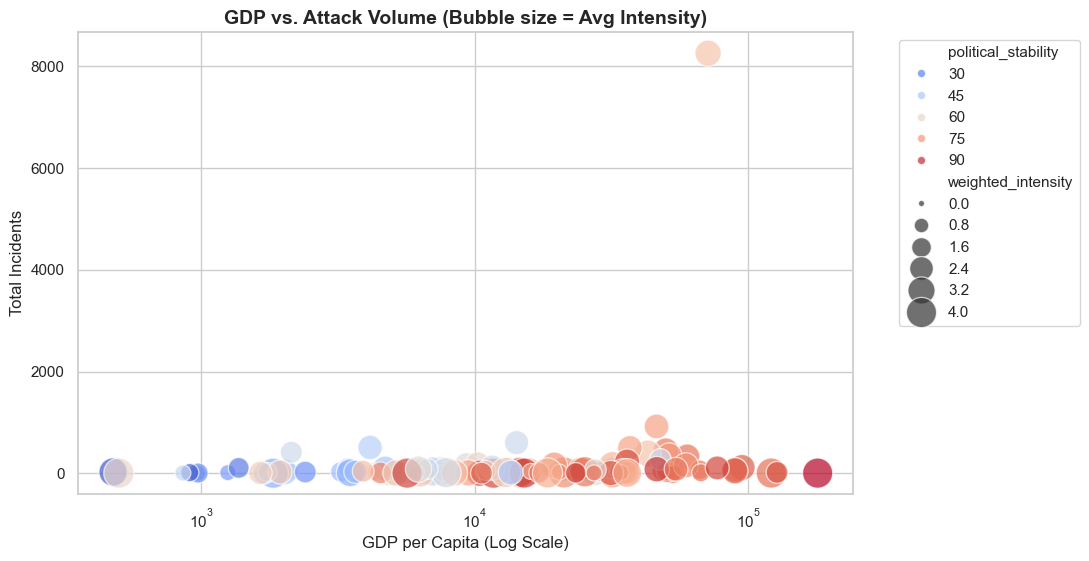

In [35]:
# Aggregate by ISO3
country_agg = df.groupby('iso3').agg({
    'motive': 'count',
    'gdp_per_capita': 'mean',
    'political_stability': 'mean',
    'weighted_intensity': 'mean'
}).rename(columns={'motive': 'total_attacks'}).reset_index()

# Tabular Visualization: Top 10 Target Countries by Average GDP
print("### Top 10 Countries by Attack Volume and Economic Standing")
display(country_agg.sort_values(by='total_attacks', ascending=False).head(10))

# Graphical Visualization: Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=country_agg, x='gdp_per_capita', y='total_attacks', size='weighted_intensity', hue='political_stability', palette='coolwarm', sizes=(20, 500), alpha=0.7)
plt.xscale('log')
plt.title('GDP vs. Attack Volume (Bubble size = Avg Intensity)', fontsize=14, fontweight='bold')
plt.xlabel('GDP per Capita (Log Scale)')
plt.ylabel('Total Incidents')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)

plt.savefig('../plots/macro_bubble_plot.png', dpi=300, bbox_inches='tight')
plt.show()

### Time-Series Analysis: Evolution of Attack Motives (2014 - 2026)

To understand how the cyber threat landscape has shifted over the last decade, we will plot the trends of the top three most common attack motives. 

### Temporal Trend: Cyber Attack Motives (2014-2026)


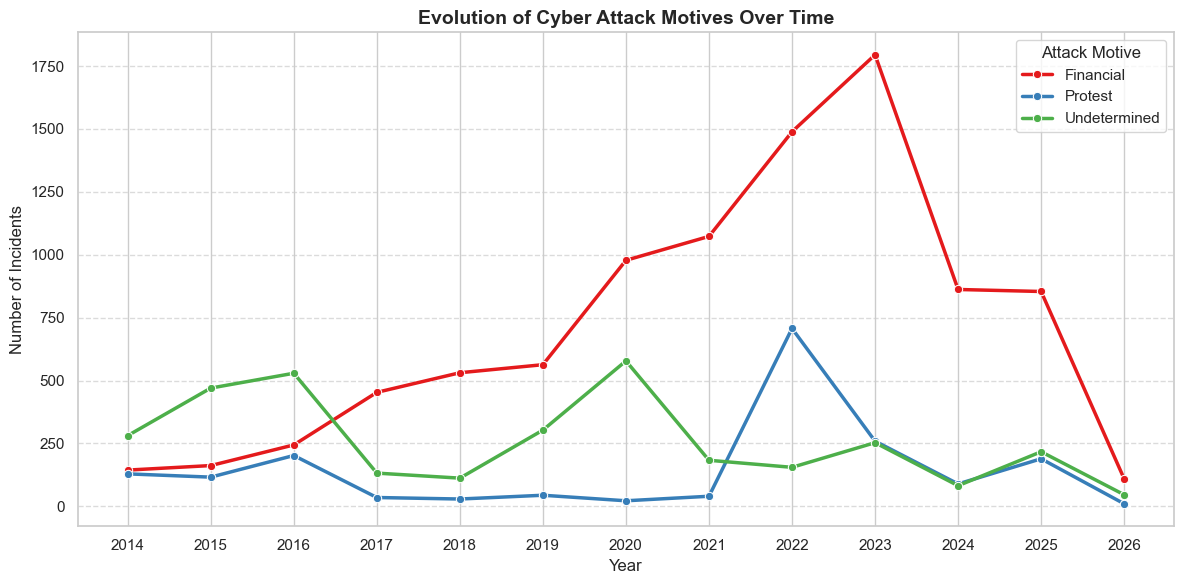

In [36]:
print("### Temporal Trend: Cyber Attack Motives (2014-2026)")

# Filter out any anomalous '0' years
time_df = df[df['year'] >= 2014].copy()

# Identify the Top 3 motives
top_3_motives = time_df['motive_clean'].value_counts().head(3).index.tolist()

# Filter the dataframe to only include these top motives
trend_df = time_df[time_df['motive_clean'].isin(top_3_motives)]

# Group by Year and Motive to count the number of incidents
trend_grouped = trend_df.groupby(['year', 'motive_clean']).size().reset_index(name='Incident Count')

# 5. Plot the Time-Series Line Chart
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=trend_grouped, 
    x='year', 
    y='Incident Count', 
    hue='motive_clean', 
    marker='o',          
    linewidth=2.5,       
    palette='Set1'
)

plt.title('Evolution of Cyber Attack Motives Over Time', fontweight='bold', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Incidents', fontsize=12)


min_year = int(trend_grouped['year'].min())
max_year = int(trend_grouped['year'].max())
plt.xticks(range(min_year, max_year + 1))

plt.legend(title='Attack Motive')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()


plt.savefig('../plots/time_series_motives.png', dpi=300, bbox_inches='tight')

plt.show()

## Multi-Variable Correlation
We look for statistical relationships between all our indicators.

### Statistical Correlation Table


,total_attacks,gdp_per_capita,political_stability,weighted_intensity
total_attacks,1.000000,0.151309,0.000032,0.069122
gdp_per_capita,0.151309,1.000000,0.536695,0.176270
political_stability,0.000032,0.536695,1.000000,0.130765
weighted_intensity,0.069122,0.176270,0.130765,1.000000


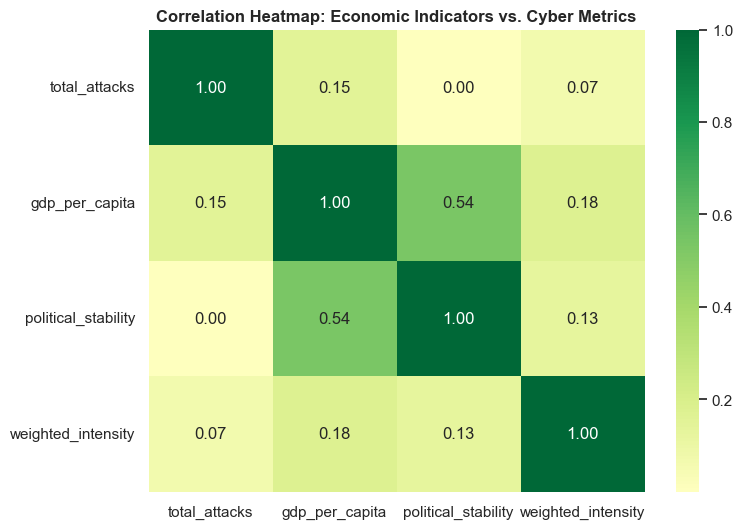

In [37]:
# Tabular Visualization: Correlation Matrix
corr_matrix = country_agg[['total_attacks', 'gdp_per_capita', 'political_stability', 'weighted_intensity']].corr()
print("### Statistical Correlation Table")
display(corr_matrix)

# Graphical Visualization: Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt=".2f")
plt.title('Correlation Heatmap: Economic Indicators vs. Cyber Metrics', fontweight='bold')

plt.savefig('../plots/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [38]:
# AGGREGATION CELL
# This creates the macro_df needed for economic trend analysis and hypothesis testing
macro_df = df.groupby(['iso3', 'year']).agg({
    'gdp_per_capita': 'mean',
    'inflation_cpi': 'mean',
    'political_stability': 'mean',
    'motive': 'count' # This gives us the number of attacks per country per year
}).rename(columns={'motive': 'total_attacks'}).reset_index()

print("Macro-level dataset created:")
display(macro_df.head())

Macro-level dataset created:


,iso3,year,gdp_per_capita,inflation_cpi,political_stability,total_attacks
0,AFG,2015,565.569730,-0.661709,23.510621,1
1,AFG,2016,522.082216,4.383892,23.472362,13
2,AFG,2018,491.337221,0.626149,21.782787,1
3,AFG,2020,510.787063,5.601888,21.658349,3
4,AFG,2021,356.496214,5.133203,24.033559,4


## Hypothesis 1: The "Stability Shock" Effect
We identify "shocks" as years where a country's Political Stability score dropped by more than 0.1 compared to the previous year. We then compare "Protest" motivated attacks in those shock years vs. the year prior.

### Mean Protest Attacks: Before vs. After Stability Shock


,Avg Protest Attacks
Period,
After Shock,2.795866
Before Shock,2.328165


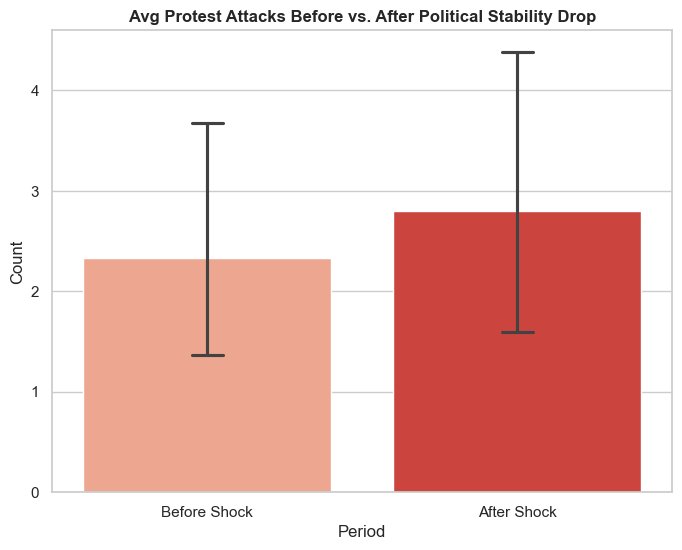

In [39]:
# Identify Shocks: Calculate Year-over-Year change in stability
# We use .diff() to see how much the score changed from the previous year
macro_df['stability_change'] = macro_df.groupby('iso3')['political_stability'].diff()
shocks = macro_df[macro_df['stability_change'] < -0.1] # Defining a "Shock" as a drop > 0.1

# Get Protest counts for those countries in the shock year and the year before
protest_data = []
for _, row in shocks.iterrows():
    country, shock_year = row['iso3'], row['year']
    
    after_count = df[
        (df['iso3'] == country) &
        (df['year'] == shock_year) &
        (df['motive_clean'] == 'Protest')
    ].shape[0]

    before_count = df[
        (df['iso3'] == country) &
        (df['year'] == shock_year - 1) &
        (df['motive_clean'] == 'Protest')
    ].shape[0]
    
    protest_data.append({'Country': country, 'Period': 'Before Shock', 'Count': before_count})
    protest_data.append({'Country': country, 'Period': 'After Shock', 'Count': after_count})

h1_plot_df = pd.DataFrame(protest_data)

# Tabular Visualization
print("### Mean Protest Attacks: Before vs. After Stability Shock")
display(h1_plot_df.groupby('Period')['Count'].mean().to_frame(name='Avg Protest Attacks'))

# Graphical Visualization
plt.figure(figsize=(8, 6))
sns.barplot(data=h1_plot_df, x='Period', y='Count', estimator='mean', palette='Reds', capsize=.1, order=['Before Shock', 'After Shock'])
plt.title('Avg Protest Attacks Before vs. After Political Stability Drop', fontweight='bold')


plt.savefig('../plots/h1_stability_shock.png', dpi=300, bbox_inches='tight')
plt.show()

## Hypothesis 2: Motive Shift During Economic Crisis
We define a "Crisis" year as any year where a country experiences Inflation > 10%. We compare the distribution of motives during these crises against the "Baseline" (all other years).

### Motive Distribution: Crisis vs. Baseline (%)


,Crisis,Baseline
motive_clean,,
Financial,0.105639,0.567186
Protest,0.500357,0.072852
Undetermined,0.093505,0.199875
Sabotage,0.097787,0.016127
Political-Espionage,0.065667,0.044707


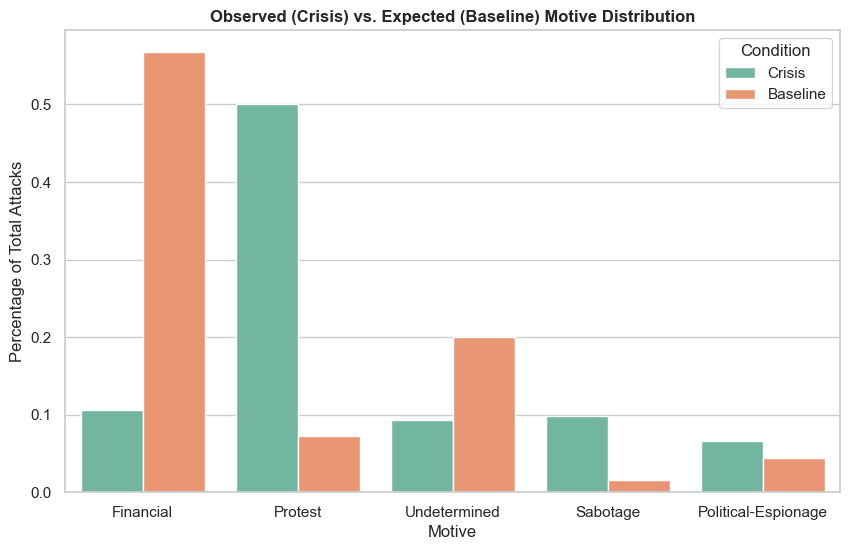

In [40]:
# Define Crisis vs Baseline
df['is_crisis'] = df['inflation_cpi'] > 10 

# Calculate full distributions for both conditions
crisis_dist = df[df['is_crisis'] == True]['motive_clean'].value_counts(normalize=True).rename('Crisis')
baseline_dist = df[df['is_crisis'] == False]['motive_clean'].value_counts(normalize=True).rename('Baseline')

# Combine into one table and replace NaNs with 0 (0%)
combined_dist = pd.concat([crisis_dist, baseline_dist], axis=1).fillna(0)

# Keep only the top 5 most common motives overall
combined_dist = combined_dist.loc[combined_dist.sum(axis=1).sort_values(ascending=False).head(5).index]

# Tabular Visualization
print("### Motive Distribution: Crisis vs. Baseline (%)")
display(combined_dist)

# Prepare data for the bar chart
h2_plot_df = combined_dist.reset_index().melt(id_vars='motive_clean', var_name='Condition', value_name='Frequency')
h2_plot_df.rename(columns={'motive_clean': 'Motive'}, inplace=True)

# Graphical Visualization
plt.figure(figsize=(10, 6))
sns.barplot(data=h2_plot_df, x='Motive', y='Frequency', hue='Condition', palette='Set2')
plt.title('Observed (Crisis) vs. Expected (Baseline) Motive Distribution', fontweight='bold')
plt.ylabel('Percentage of Total Attacks')
plt.savefig('../plots/h2_motive_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Hypothesis 3: Target Country Wealth by Attack Motive
We investigate whether specific cyber attack motives are associated with the economic stature of the target nation. We compare the average GDP across the three primary motives (Financial, Protest, and Political-Espionage) to determine if threat actors systematically select targets based on national wealth.

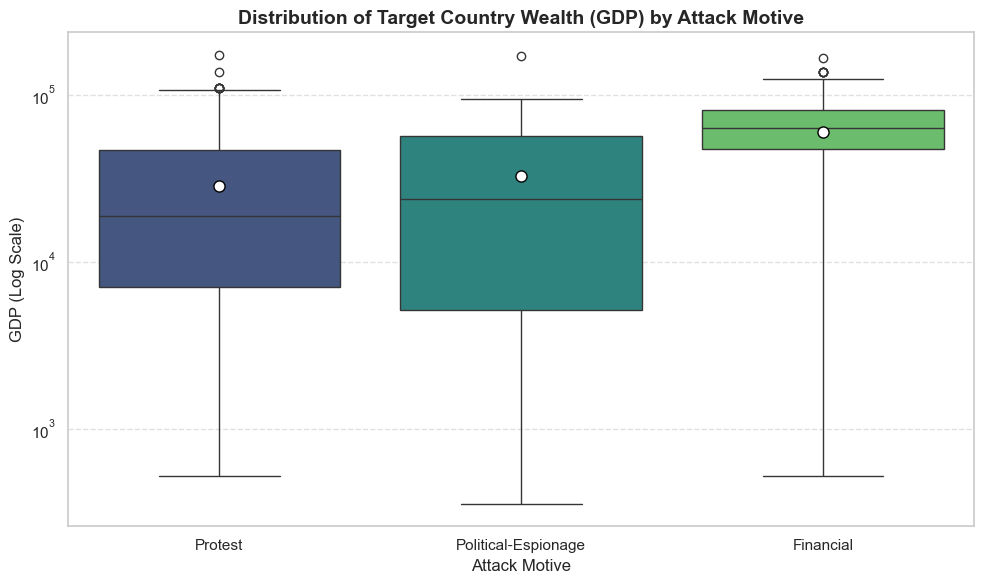

In [41]:
# Identify the correct GDP column
target_col = 'gdp_per_capita' if 'gdp_per_capita' in df.columns else 'gdp'

# Clean the motives
df['motive_plot'] = df['motive_clean'].astype(str).str.strip()

# Filter for the specific motives we want
valid_motives = ['Financial', 'Protest', 'Political-Espionage']
eda_plot_df = df[df['motive_plot'].isin(valid_motives)].copy()

# Drop NaNs for the plot to render
eda_plot_df = eda_plot_df.dropna(subset=[target_col])

if eda_plot_df.empty:
    print("Error: No data found! Check your column names or motive labels.")
    print(f"Available motives in data: {df['motive_plot'].unique()}")
else:
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=eda_plot_df, 
        x='motive_plot', 
        y=target_col, 
        palette='viridis',
        showmeans=True,
        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
    )

    plt.title('Distribution of Target Country Wealth (GDP) by Attack Motive', fontweight='bold', fontsize=14)
    plt.ylabel('GDP (Log Scale)', fontsize=12)
    plt.xlabel('Attack Motive', fontsize=12)
    plt.yscale('log') 
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()

    plt.savefig('../plots/gdp_by_motive_boxplot.png', dpi=300, bbox_inches='tight')
    plt.show()